# Linear Regression practice

- f_wb(x) = w*x+b
- f_x = wx+b


In [49]:
import numpy as np
import matplotlib.pyplot as plt

X_train = np.array([1.0 , 2.0])
y_train = np.array([300.0,500.0])

print(f"x_train = {X_train}")
print(f"y_train = {y_train}")


x_train = [1. 2.]
y_train = [300. 500.]


In [50]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
m = X_train.shape[0]
print(f"Number of training examples is: {m}")


X_train shape: (2,)
y_train shape: (2,)
Number of training examples is: 2


In [51]:
i = 0
x_i = X_train[i]
y_i = y_train[i]
print(f"(x^({i}), y^({i})) = ({x_i}, {y_i})")


(x^(0), y^(0)) = (1.0, 300.0)


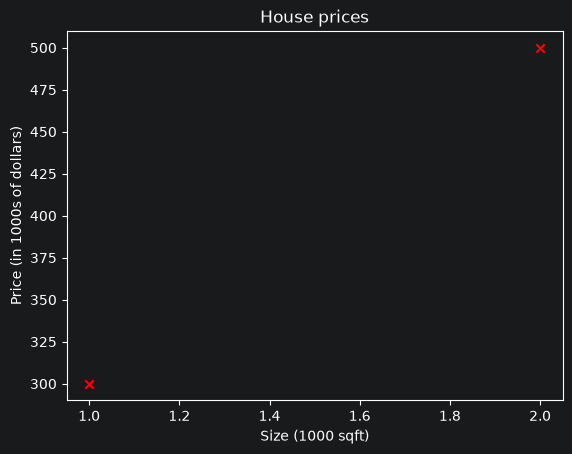

In [52]:
plt.scatter(X_train ,y_train , marker='x', c='r')
plt.title("House prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')

plt.show()

In [53]:
w =100
b = 100

print(f"w : {w}")
print(f"b : {b}")


w : 100
b : 100


In [54]:
def compute_model_output(x ,w ,b):
    """
    Basic linear regression model
    :param x:
    :param w:
    :param b:
    :return:
    """
    m = x.shape[0]
    f_wb = np.zeros(m)
    print(f"f_wb shape: {f_wb.shape} and x shape: {x.shape}")

    for i in range(m):
        f_wb[i] =w * x[i] +b
    # vs
    f_wb = np.dot(w,x)+b

    return f_wb

f_wb shape: (2,) and x shape: (2,)


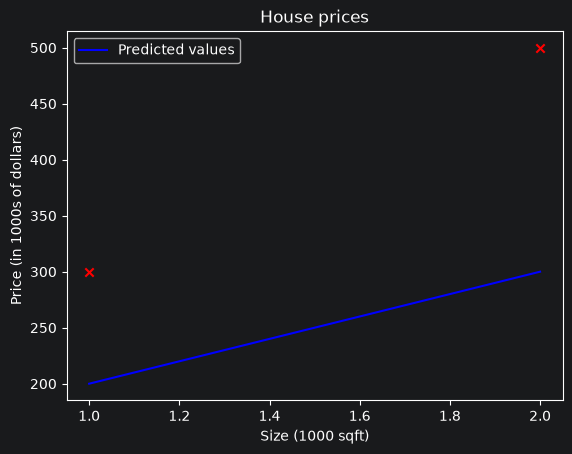

In [55]:
tmp_f_wb = compute_model_output(X_train , w , b)

plt.plot(X_train , tmp_f_wb , c='b' , label='Predicted values')
plt.scatter(X_train , y_train , marker='x', c='r')
plt.title("House prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()

In [56]:
w = 200
b = 100
x_i = 1.2

cost_1200sqft = w * x_i + b
print(f"Cost for 1200 sqft house is: {cost_1200sqft}")

Cost for 1200 sqft house is: 340.0


$$J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

In [57]:
def compute_cost(X , y , w ,b):
    """
    Compute cost function
    """

    m = X.shape[0]
    cost_sum = 0

    for i in range(m):
        f_wb = np.dot(w,X[i]) + b
        cost = (f_wb - y[i])**2
        cost_sum += cost

    total_cost = (1/(2*m))*cost_sum

    return total_cost

cost = compute_cost(X_train , y_train , w , b)
print(f"Cost at w={w}, b={b}: {cost}")

Cost at w=200, b=100: 0.0


Формулы частных производных:$$\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) x^{(i)}$$$$\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})$$

In [58]:
def compute_gradient(x , y , w ,b):
    """
    Computes the gradient for linear regression.
    """
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = np.dot(w,x[i]) +b

        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = (f_wb - y[i])

        dj_dw+=dj_dw_i
        dj_db+=dj_db_i

    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw , dj_db



# Gradient descent
$$w = w - \alpha \frac{\partial J(w,b)}{\partial w}$$$$b = b - \alpha \frac{\partial J(w,b)}{\partial b}$$

In [61]:
def gradient_descent(x , y , w_in ,b_in , alpha , num_iters, cost_function, gradient_function):
    """
    Performs gradient descent to fit w, b.
    """

    w = w_in
    b = b_in

    J_hist = []


    for i in range(num_iters):
        dj_dw , dj_db = compute_gradient(x , y , w , b)

        w = w - alpha * dj_dw
        b = b- alpha * dj_db


        if i < 100000:
            J_hist.append(compute_cost(x, y, w, b))


        if i % (num_iters//10) == 0:
            print(f"Iteration :{i:5d} , Cost : {J_hist[-1]:8.2f} |w: {w:8.3f}, b: {b:8.3f}")

    return w , b , J_hist


Iteration :    0 , Cost : 79274.81 |w:    6.500, b:    4.000
Iteration : 1000 , Cost :     3.41 |w:  194.915, b:  108.228
Iteration : 2000 , Cost :     0.79 |w:  197.549, b:  103.966
Iteration : 3000 , Cost :     0.18 |w:  198.818, b:  101.912
Iteration : 4000 , Cost :     0.04 |w:  199.430, b:  100.922
Iteration : 5000 , Cost :     0.01 |w:  199.725, b:  100.444
Iteration : 6000 , Cost :     0.00 |w:  199.868, b:  100.214
Iteration : 7000 , Cost :     0.00 |w:  199.936, b:  100.103
Iteration : 8000 , Cost :     0.00 |w:  199.969, b:  100.050
Iteration : 9000 , Cost :     0.00 |w:  199.985, b:  100.024

Final learned parameters: w = 199.99, b = 100.01
f_wb shape: (2,) and x shape: (2,)


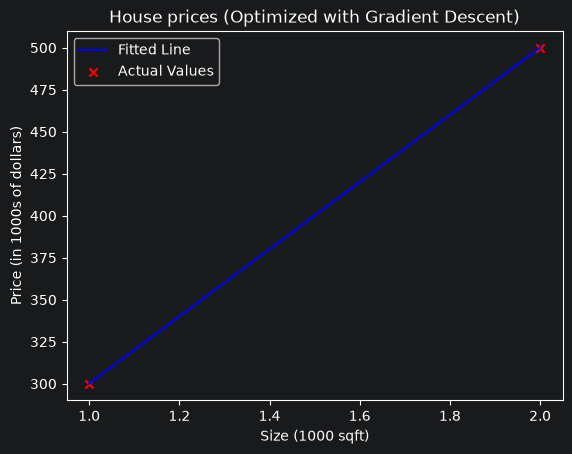

In [62]:
# Инициализация параметров
w_init = 0.0
b_init = 0.0
iterations = 10000
alpha = 0.01

# Запуск обучения
w_final, b_final, J_hist = gradient_descent(
    X_train, y_train, w_init, b_init, alpha, iterations, compute_cost, compute_gradient
)

print(f"\nFinal learned parameters: w = {w_final:.2f}, b = {b_final:.2f}")

# Построение итоговой прямой
tmp_f_wb = compute_model_output(X_train, w_final, b_final)

plt.plot(X_train, tmp_f_wb, c='b', label='Fitted Line')
plt.scatter(X_train, y_train, marker='x', c='r', label='Actual Values')
plt.title("House prices (Optimized with Gradient Descent)")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()